In [8]:
import pandas as pd
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv.zip")
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [ ]:
matches.shape

(1095, 20)

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
matches["winner"].value_counts()

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


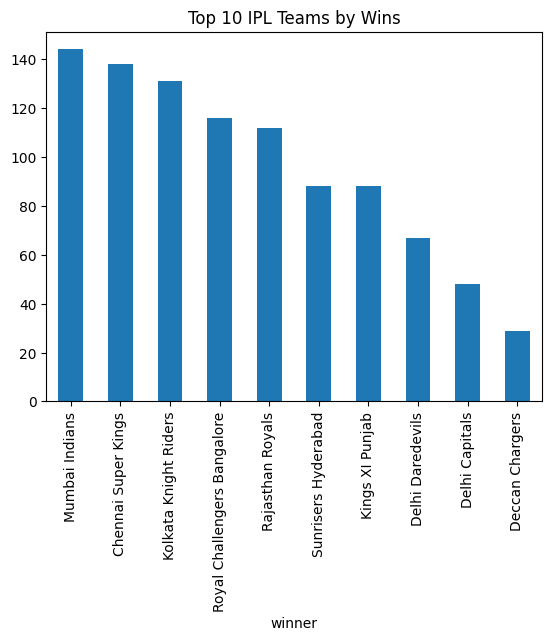

In [ ]:
import matplotlib.pyplot as plt
#Plot 10 teams with the most wins
matches["winner"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 IPL Teams by Wins")
plt.show()

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


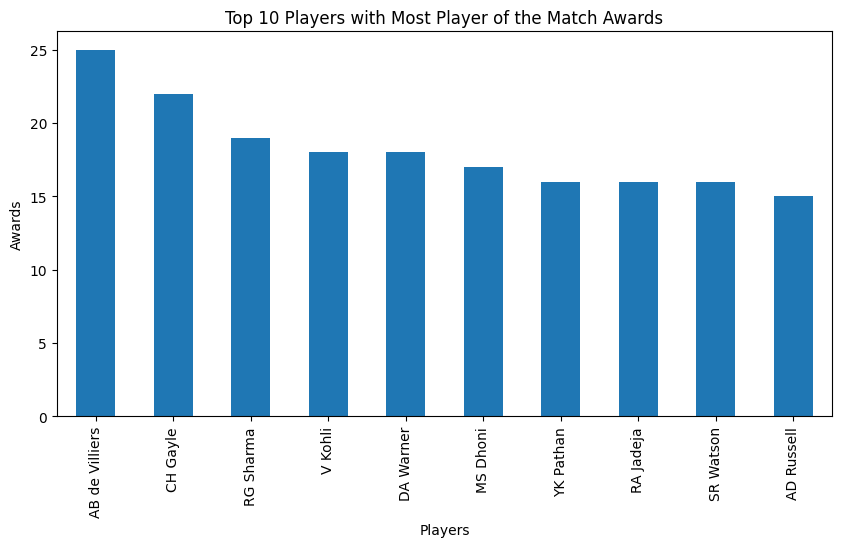

In [ ]:
#Players with the most player of match awards
top_players = matches["player_of_match"].value_counts().head(10)

print(top_players)

top_players.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xlabel("Players")
plt.ylabel("Awards")

plt.show()

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


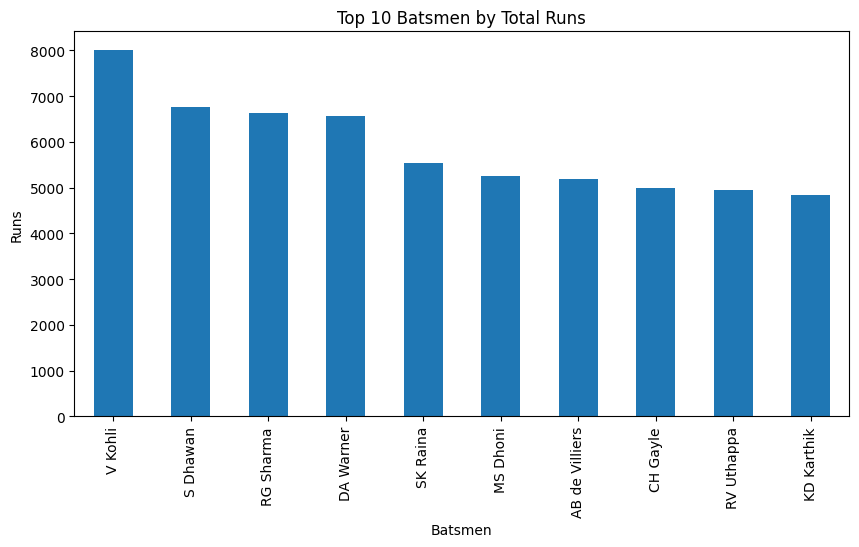

In [ ]:
# Top Batsmen in IPL History
top_batsmen = deliveries.groupby("batter")["batsman_runs"].sum()
top_batsmen = top_batsmen.sort_values(ascending=False).head(10)

print(top_batsmen)

top_batsmen.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Batsmen")
plt.ylabel("Runs")

plt.show()

In [ ]:
# Calculating Strike Rate of Players
runs = deliveries.groupby("batter")["batsman_runs"].sum()
balls = deliveries.groupby("batter")["ball"].count()
strike_rate = (runs / balls) * 100
top_strike_rate = strike_rate.sort_values(ascending=False).head(10)

print(top_strike_rate)

batter
L Wood             300.000000
B Stanlake         250.000000
J Fraser-McGurk    220.000000
R Sai Kishore      216.666667
Umar Gul           205.263158
RS Sodhi           200.000000
Shahid Afridi      176.086957
I Malhotra         175.000000
WG Jacks           172.932331
PD Salt            169.610390
dtype: float64


In [ ]:
# Toss Winner vs Match Winner Analysis
toss_match_win = matches[matches["toss_winner"] == matches["winner"]]

percentage = (len(toss_match_win) / len(matches)) * 100

print("Percentage of matches where toss winner also won the match:", percentage)

Percentage of matches where toss winner also won the match: 50.593607305936075


venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


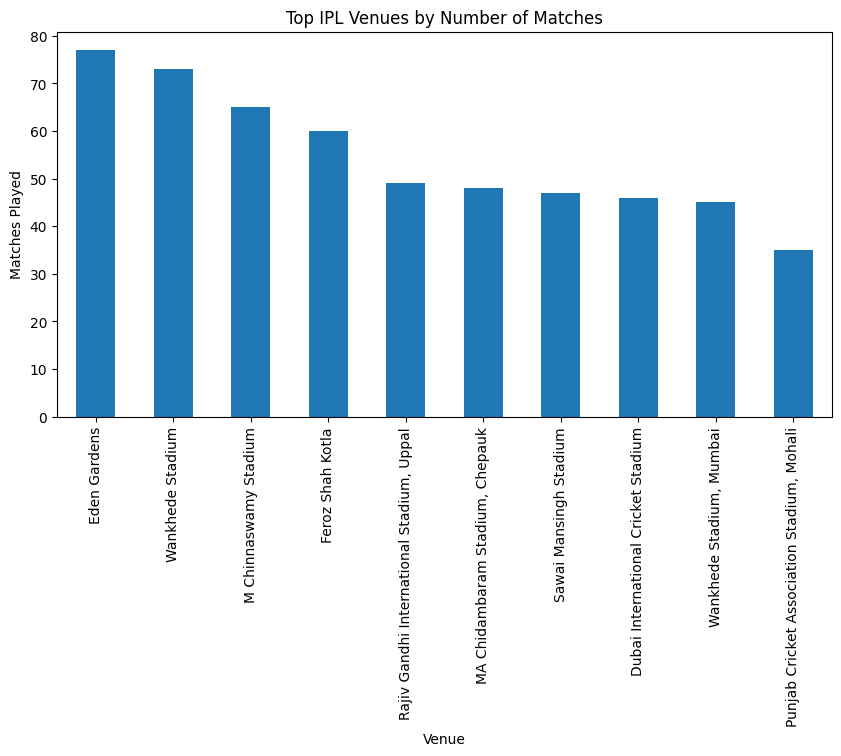

In [ ]:
# Most Frequently Used IPL Venues
venues = matches["venue"].value_counts().head(10)
print(venues)
venues.plot(kind="bar", figsize=(10,5))

plt.title("Top IPL Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Matches Played")

plt.show()

      season                 winner  wins
6    2007/08       Rajasthan Royals    13
10      2009       Delhi Daredevils    10
21   2009/10         Mumbai Indians    11
24      2011    Chennai Super Kings    11
38      2012  Kolkata Knight Riders    12
47      2013         Mumbai Indians    13
54      2014        Kings XI Punjab    12
60      2015    Chennai Super Kings    10
75      2016    Sunrisers Hyderabad    11
80      2017         Mumbai Indians    12
84      2018    Chennai Super Kings    11
96      2019         Mumbai Indians    11
104  2020/21         Mumbai Indians    11
108     2021    Chennai Super Kings    11
118     2022         Gujarat Titans    12
128     2023         Gujarat Titans    11
139     2024  Kolkata Knight Riders    11


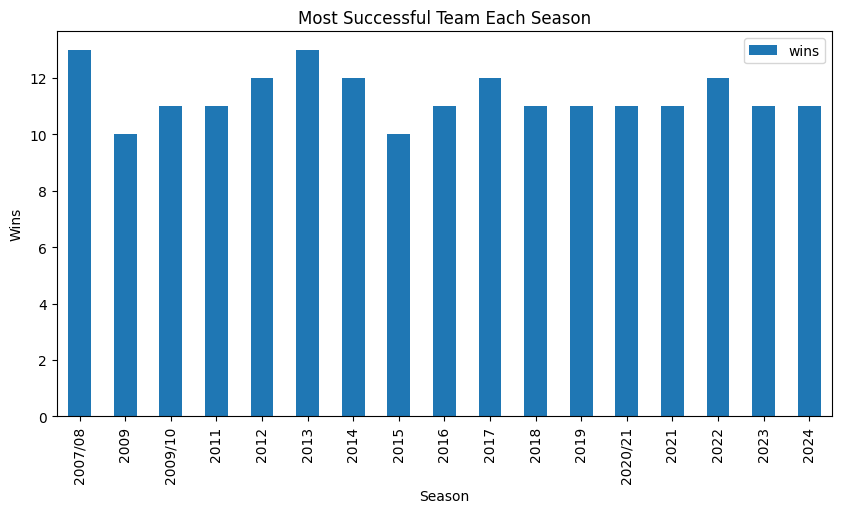

In [ ]:
#Team performance by seasons
season_team_wins = matches.groupby(["season","winner"]).size().reset_index(name="wins")
top_season_teams = season_team_wins.sort_values(["season","wins"], ascending=[True,False]).groupby("season").head(1)

print(top_season_teams)
top_season_teams.plot(x="season", y="wins", kind="bar", figsize=(10,5))

plt.title("Most Successful Team Each Season")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.show()

venue
Eden Gardens                                  22443
Wankhede Stadium                              22175
M Chinnaswamy Stadium                         19139
Feroz Shah Kotla                              17499
Wankhede Stadium, Mumbai                      14744
MA Chidambaram Stadium, Chepauk               14472
Rajiv Gandhi International Stadium, Uppal     14179
Dubai International Cricket Stadium           13753
Sawai Mansingh Stadium                        13473
Punjab Cricket Association Stadium, Mohali    10421
Name: batsman_runs, dtype: int64


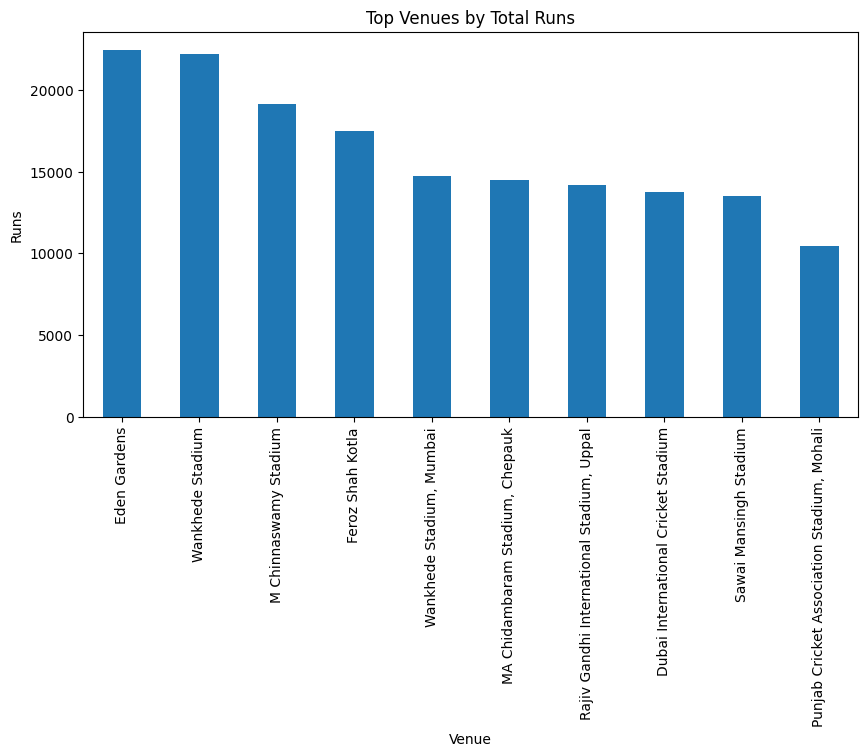

In [ ]:
#Top run scoring venues
venue_runs = deliveries.merge(matches[["id","venue"]], left_on="match_id", right_on="id")

venue_run_totals = venue_runs.groupby("venue")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print(venue_run_totals)
venue_run_totals.plot(kind="bar", figsize=(10,5))

plt.title("Top Venues by Total Runs")
plt.xlabel("Venue")
plt.ylabel("Runs")
plt.show()

In [ ]:
#Average runs Per match
runs_per_match = deliveries.groupby("match_id")["batsman_runs"].sum()
average_runs = runs_per_match.mean()
print("Average runs per IPL match:", average_runs)

Average runs per IPL match: 301.4283105022831


In [ ]:
# Best power hitter
runs = deliveries.groupby("batter")["batsman_runs"].sum()

balls = deliveries.groupby("batter")["ball"].count()

strike_rate = (runs / balls) * 100

batsman_stats = pd.DataFrame({
    "Runs": runs,
    "Balls": balls,
    "StrikeRate": strike_rate
})

batsman_stats = batsman_stats[batsman_stats["Runs"] > 1000]

top_power_hitters = batsman_stats.sort_values("StrikeRate", ascending=False).head(10)

print(top_power_hitters)

                 Runs  Balls  StrikeRate
batter                                  
AD Russell       2488   1515  164.224422
SP Narine        1534    984  155.894309
N Pooran         1769   1143  154.768154
GJ Maxwell       2772   1842  150.488599
Abhishek Sharma  1377    925  148.864865
V Sehwag         2728   1833  148.827059
AB de Villiers   5181   3487  148.580442
YBK Jaiswal      1607   1095  146.757991
SO Hetmyer       1243    854  145.550351
RR Pant          3297   2296  143.597561


toss_decision
field    704
bat      391
Name: count, dtype: int64


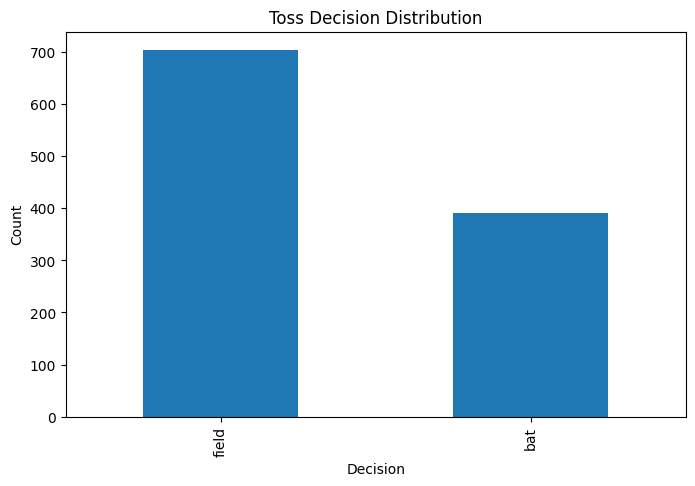

In [ ]:
#Toss decision Analysis
toss_decision = matches["toss_decision"].value_counts()
print(toss_decision)
toss_decision.plot(kind="bar", figsize=(8,5))
plt.title("Toss Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64


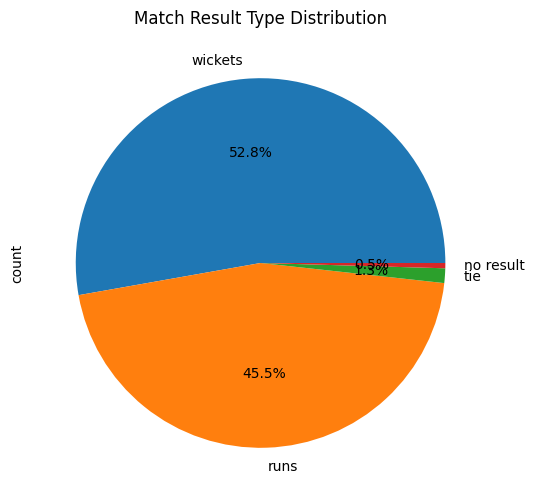

In [ ]:
# Matches won by Runs vs won by wickets
win_type = matches["result"].value_counts()
print(win_type)
win_type.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Match Result Type Distribution")
plt.show()

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: count, dtype: int64


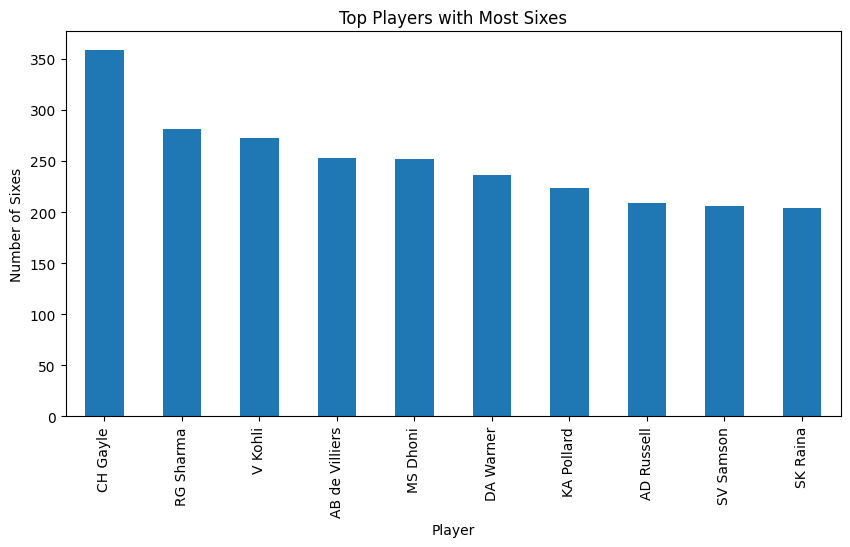

In [ ]:
# Top six hitters
sixes = deliveries[deliveries["batsman_runs"] == 6]["batter"].value_counts().head(10)
print(sixes)
sixes.plot(kind="bar", figsize=(10,5))
plt.title("Top Players with Most Sixes")
plt.xlabel("Player")
plt.ylabel("Number of Sixes")
plt.show()

over
0     12394
1     14897
2     16934
3     17510
4     17753
5     17641
6     14035
7     15260
8     15915
9     15638
10    16116
11    16393
12    16399
13    16899
14    17373
15    17604
16    18040
17    18526
18    18033
19    16704
Name: batsman_runs, dtype: int64


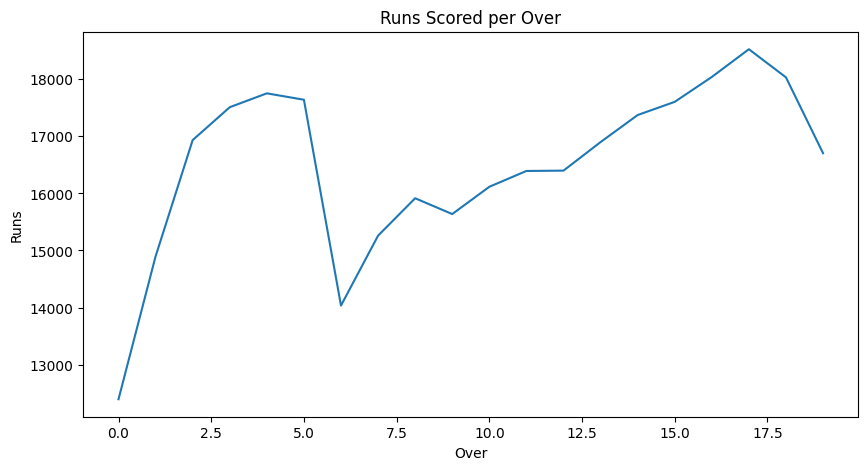

In [ ]:
# Run distributions per over
runs_per_over = deliveries.groupby("over")["batsman_runs"].sum()
print(runs_per_over)
runs_per_over.plot(figsize=(10,5))
plt.title("Runs Scored per Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

toss_winner
Mumbai Indians                 143
Kolkata Knight Riders          122
Chennai Super Kings            121
Rajasthan Royals               118
Royal Challengers Bangalore    112
Sunrisers Hyderabad             88
Kings XI Punjab                 85
Delhi Daredevils                79
Delhi Capitals                  50
Deccan Chargers                 43
Name: winner, dtype: int64


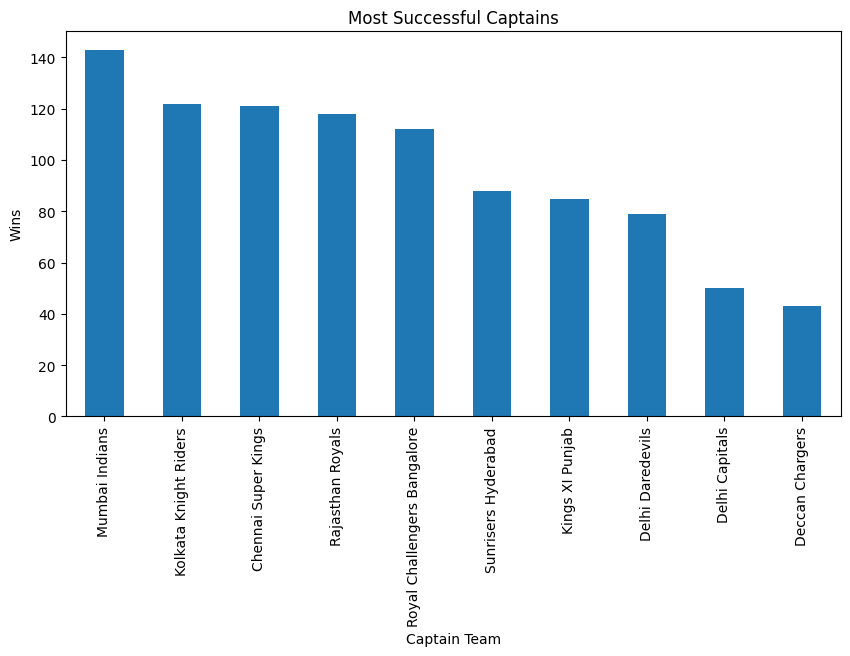

In [ ]:
# Most successful captains
captain_wins = matches.groupby("toss_winner")["winner"].count().sort_values(ascending=False).head(10)
print(captain_wins)
captain_wins.plot(kind="bar", figsize=(10,5))
plt.title("Most Successful Captains")
plt.xlabel("Captain Team")
plt.ylabel("Wins")
plt.show()

In [ ]:
# Highest Team scores
team_scores = deliveries.groupby(["match_id","batting_team"])["total_runs"].sum().reset_index()
highest_scores = team_scores.sort_values("total_runs", ascending=False).head(10)
print(highest_scores)

      match_id                 batting_team  total_runs
2104   1426268          Sunrisers Hyderabad         287
2060   1422126          Sunrisers Hyderabad         277
2076   1422134        Kolkata Knight Riders         272
2114   1426273          Sunrisers Hyderabad         266
702     598027  Royal Challengers Bangalore         263
2128   1426280                 Punjab Kings         262
2103   1426268  Royal Challengers Bengaluru         262
2127   1426280        Kolkata Knight Riders         261
1972   1359512         Lucknow Super Giants         257
2129   1426281               Delhi Capitals         257


bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64


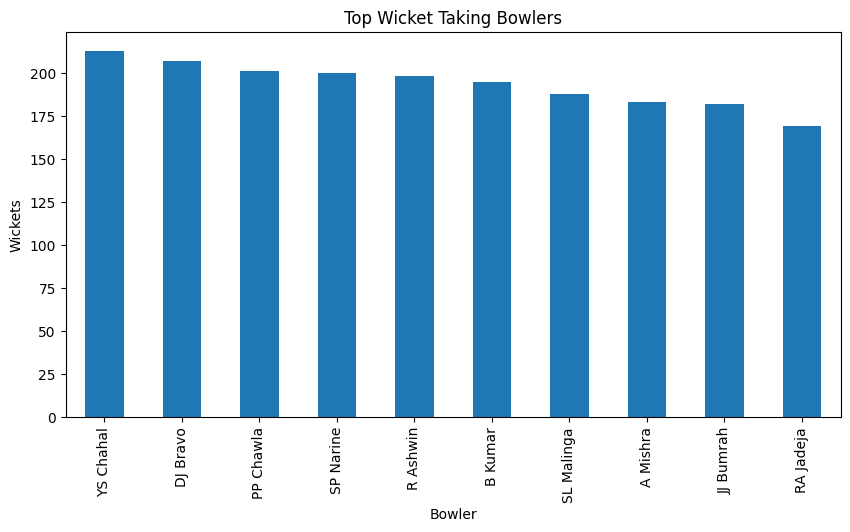

In [ ]:
#Wickets by Bowlers
wickets = deliveries[deliveries["dismissal_kind"].notna()]
top_wickets = wickets["bowler"].value_counts().head(10)
print(top_wickets)
top_wickets.plot(kind="bar", figsize=(10,5))
plt.title("Top Wicket Taking Bowlers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

In [ ]:
# Match winner prediction model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = matches[["team1","team2","toss_winner","toss_decision","venue","winner"]]
data = data.dropna()
encoder = LabelEncoder()
for col in ["team1","team2","toss_winner","toss_decision","venue"]:
    data[col] = encoder.fit_transform(data[col])

y_encoder = LabelEncoder()
data["winner"] = y_encoder.fit_transform(data["winner"])
X = data.drop("winner", axis=1)
y = data["winner"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestClassifier()
model.fit(X_train,y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.45871559633027525


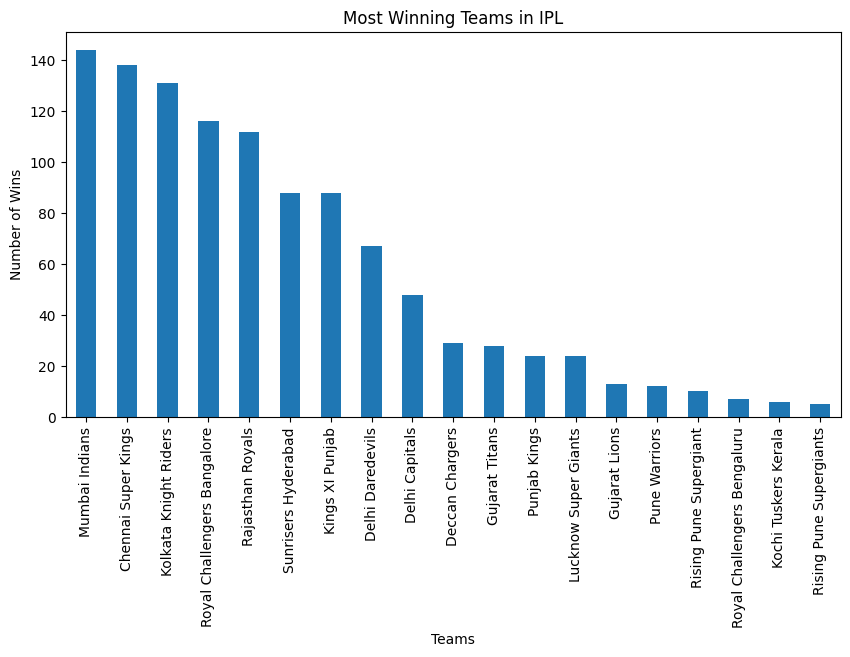

In [11]:
import matplotlib.pyplot as plt

matches["winner"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Most Winning Teams in IPL")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")

plt.show()

In [14]:
print(type(matches))

<class 'pandas.core.frame.DataFrame'>


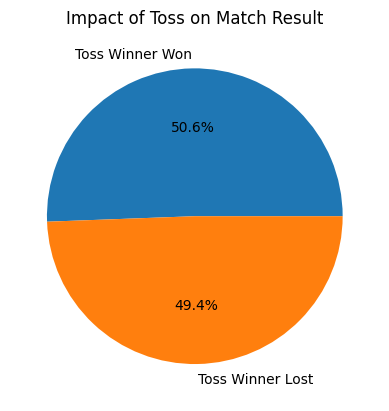

In [15]:
toss_win = matches[matches["toss_winner"] == matches["winner"]]

labels = ["Toss Winner Won", "Toss Winner Lost"]
sizes = [len(toss_win), len(matches) - len(toss_win)]

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Impact of Toss on Match Result")
plt.show()

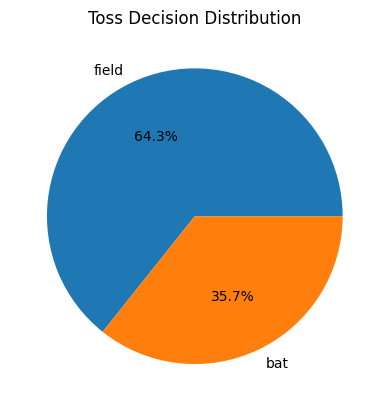

In [16]:
matches["toss_decision"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Toss Decision Distribution")
plt.ylabel("")

plt.show()

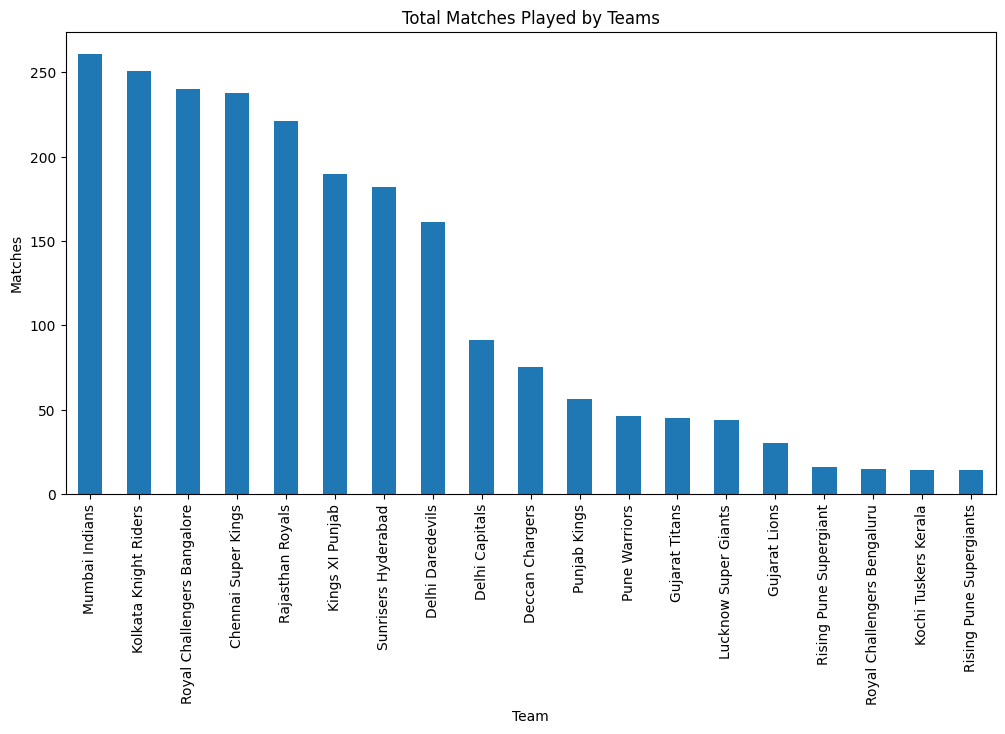

In [17]:
team1_matches = matches["team1"].value_counts()
team2_matches = matches["team2"].value_counts()

total_matches = team1_matches.add(team2_matches, fill_value=0)

total_matches.sort_values(ascending=False).plot(kind="bar", figsize=(12,6))

plt.title("Total Matches Played by Teams")
plt.xlabel("Team")
plt.ylabel("Matches")
plt.show()

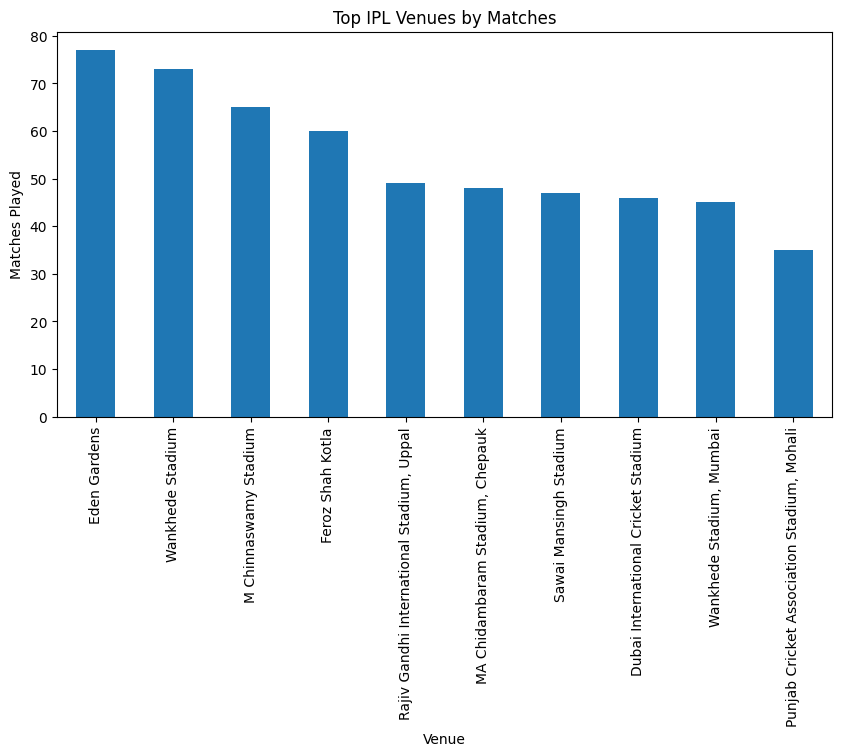

In [18]:
matches["venue"].value_counts().head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top IPL Venues by Matches")
plt.xlabel("Venue")
plt.ylabel("Matches Played")
plt.show()

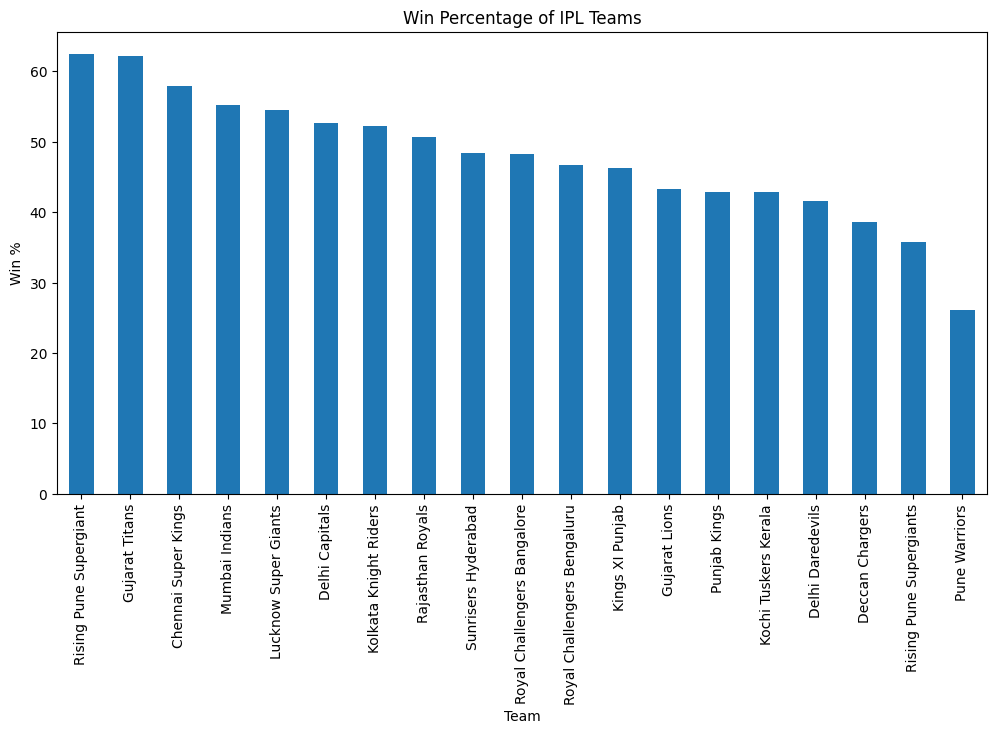

In [19]:
wins = matches["winner"].value_counts()

matches_played = total_matches

win_percentage = (wins / matches_played) * 100

win_percentage.sort_values(ascending=False).plot(kind="bar", figsize=(12,6))

plt.title("Win Percentage of IPL Teams")
plt.xlabel("Team")
plt.ylabel("Win %")
plt.show()

In [20]:
matches.groupby("season")["winner"].value_counts().head(10)

season   winner                     
2007/08  Rajasthan Royals               13
         Kings XI Punjab                10
         Chennai Super Kings             9
         Delhi Daredevils                7
         Mumbai Indians                  7
         Kolkata Knight Riders           6
         Royal Challengers Bangalore     4
         Deccan Chargers                 2
2009     Delhi Daredevils               10
         Deccan Chargers                 9
Name: count, dtype: int64

In [21]:
#data cleaning
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [24]:
# Drop unnecessary columns
matches = matches.drop(["umpire1","umpire2"], axis=1)

In [26]:
#feature engineering
#train data for ML
matches_ml = matches[["team1","team2","toss_winner","toss_decision","venue","winner"]]

In [27]:
#encode categorical columns
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in matches_ml.columns:
    matches_ml[col] = encoder.fit_transform(matches_ml[col])

/tmp/ipykernel_2930/181251978.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_ml[col] = encoder.fit_transform(matches_ml[col])
/tmp/ipykernel_2930/181251978.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_ml[col] = encoder.fit_transform(matches_ml[col])
/tmp/ipykernel_2930/181251978.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

In [28]:
#Train Test Split
from sklearn.model_selection import train_test_split

X = matches_ml.drop("winner", axis=1)
y = matches_ml["winner"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [30]:
#Evaluate Model
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4748858447488584


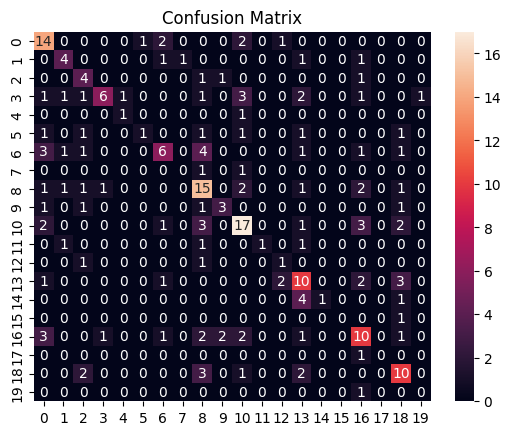

In [31]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

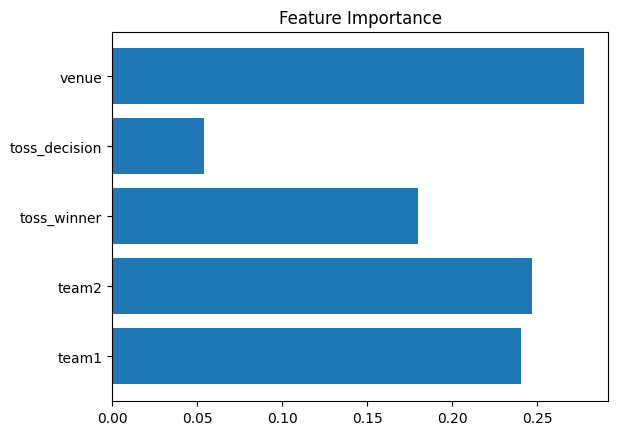

In [32]:
#Feature Importance
importance = model.feature_importances_

plt.barh(X.columns, importance)

plt.title("Feature Importance")
plt.show()

In [33]:
#Predict new Match
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Winner:", prediction)

Predicted Winner: [6]
